### The Transformer Block

In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

The Building Blocks:

1. Layer Normalization 
2. GELU
3. Feed Forward Neural Network 
4. Shortcut Connections

In [2]:
import torch 
from torch import nn

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim) 
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2) 
        
        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec
    
    

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim)) #a hyperparameter which will be trained, has the same dimension as the input 
        self.shift = nn.Parameter(torch.zeros(emb_dim))#another hyperparameter which will be added that's why 0

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x-mean) / torch.sqrt(var + self.eps)  #eps is added so that if in any case var becomes 0 the entire term don't become 0 
        return self.scale * norm_x + self.shift #scale and shift are hyperparams which will be trained 
    #you can see here why scale was made all 1 and shift as all 0s


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))   #this is the function which is actually used for calculating gelu, this is an approximation of the original 
            #cumulative distributive fucntion of gradient distribution 
        ))
    

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential( #sequential is a pytorch for stacking and chaining the layers toghther to create a nn
            nn.Linear(cfg["emb_dim"], 4 * cfg['emb_dim']),  #expands four times the dimension
            #input to the layer is the org embed dim, while output is 4 times the original dim 
            GELU(), #activation functin from above class
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])  #contracts back to original by reducing 4 times
            #input is 4 times the org dim, as given by the prev linear layer and output is 4 times shrinked dimenension equal to the org.
        )
    
    def forward(self, x):
        return self.layers(x)

Let us code a transformer block as follows:

Step 1: Shortcut connection for attention block

Step 2: Shortcut connection for feed forward block

Step 3: Add the original input back

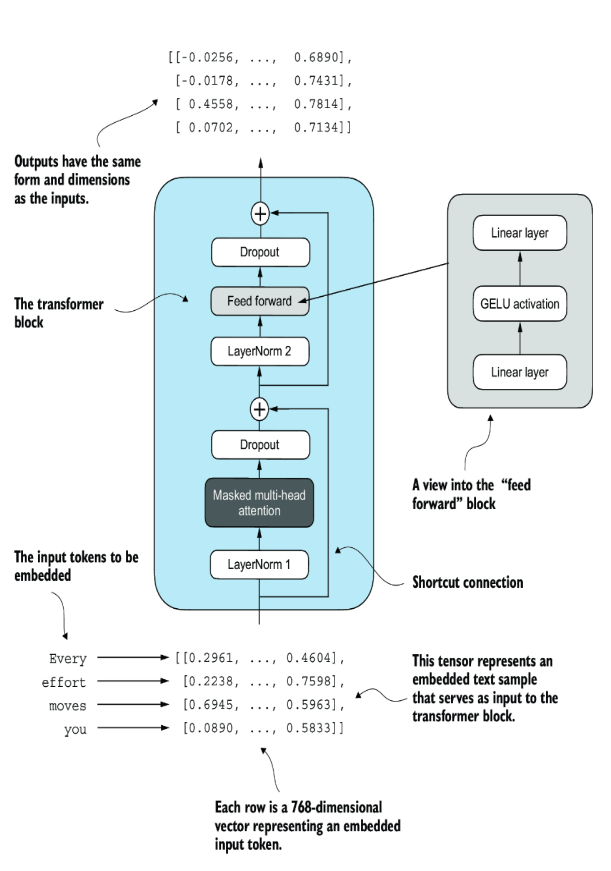

We will build the tranformer block in the same order as shown in the image

In [3]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):

        #shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)  #first normalization layer 
        x = self.att(x) #shape [batch_size, num_tokens, emb_size]  #created context vector by passing masked multi head attention 
        x = self.drop_shortcut(x) #drop 10% neurons randomly 
        x = x + shortcut #add the original input back - shortcut connection 

        #shortcut connection for feed forward block 
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x


The given code defines a TransformerBlock class in PyTorch that includes a multi-head attention mechanism (MultiHeadAttention) and a feed forward network (FeedForward), both configured based on a provided configuration dictionary (cfg), such as GPT_CONFIG_124M

Layer normalization (LayerNorm) is applied before each of these two components, and dropout is applied after them to regularize the model and prevent overfitting.

This is also known as Pre-LayerNorm.

Older architectures, such as the original transformer model, applied layer normalization after the self-attention and feed-forward networks instead, known as Post-LayerNorm, which often leads to worse training dynamics.

The class also implements the forward pass, where each component is followed by a shortcut connection that adds the input of the block to its output. This critical feature helps gradients flow through the network during training and improves the learning of deep models

In [4]:
#Create sample input of shape [batch_size, num_tokens, emb_dim]

torch.manual_seed(123)
x = torch.rand(2, 4, 768) #A
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)
print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


As we can see from the code output, the transformer block maintains the input dimensions in its output, indicating that the transformer architecture processes sequences of data without altering their shape throughout the network.

The preservation of shape throughout the transformer block architecture is not incidental but a crucial aspect of its design.

This design enables its effective application across a wide range of sequence-to-sequence tasks, where each output vector directly corresponds to an input vector, maintaining a one-to-one relationship.

In [5]:
import torch 
from torch import nn

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        print("\n=== MultiHeadAttention ===")
        print(f"Input shape: {x.shape}")  # (batch_size, num_tokens, d_in)

        b, num_tokens, d_in = x.shape

        keys = self.W_key(x) 
        queries = self.W_query(x)
        values = self.W_value(x)
        print(f"After Linear (K, Q, V) shape: {keys.shape}")  # (b, num_tokens, d_out)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        print(f"After Reshape and Transpose (K, Q, V) shape: {keys.shape}")  # (b, num_heads, num_tokens, head_dim)

        attn_scores = queries @ keys.transpose(2, 3)  # (b, num_heads, num_tokens, num_tokens)
        print(f"Attention Scores shape: {attn_scores.shape}")

        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        attn_weights = torch.softmax(attn_scores / (self.head_dim ** 0.5), dim=-1)
        attn_weights = self.dropout(attn_weights)
        print(f"Attention Weights shape: {attn_weights.shape}")

        context_vec = (attn_weights @ values).transpose(1, 2).contiguous().view(b, num_tokens, self.d_out)
        print(f"Context Vector shape: {context_vec.shape}")

        context_vec = self.out_proj(context_vec)
        print(f"Output shape: {context_vec.shape}")
        return context_vec


class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        print("\n=== LayerNorm ===")
        print(f"Input shape: {x.shape}")
        
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        
        output = self.scale * norm_x + self.shift
        print(f"Output shape: {output.shape}")
        return output


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        print("\n=== GELU Activation ===")
        print(f"Input shape: {x.shape}")
        
        output = 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))
        ))

        print(f"Output shape: {output.shape}")
        return output


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
        )
    
    def forward(self, x):
        print("\n=== FeedForward ===")
        print(f"Input shape: {x.shape}")
        
        output = self.layers(x)
        
        print(f"Output shape: {output.shape}")
        return output


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        print("\n=== TransformerBlock ===")
        print(f"Input shape: {x.shape}")

        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Residual Connection
        print(f"After Attention + Residual shape: {x.shape}")

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Residual Connection
        print(f"After FeedForward + Residual shape: {x.shape}")

        return x


# Sample Config
GPT_CONFIG_124M = {
    "emb_dim": 768,
    "context_length": 4,
    "n_heads": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

# Create sample input of shape [batch_size, num_tokens, emb_dim]
torch.manual_seed(123)
x = torch.rand(2, 4, 768)  # (batch_size=2, num_tokens=4, embedding_dim=768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("\n=== Final Output ===")
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")



=== TransformerBlock ===
Input shape: torch.Size([2, 4, 768])

=== LayerNorm ===
Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])

=== MultiHeadAttention ===
Input shape: torch.Size([2, 4, 768])
After Linear (K, Q, V) shape: torch.Size([2, 4, 768])
After Reshape and Transpose (K, Q, V) shape: torch.Size([2, 12, 4, 64])
Attention Scores shape: torch.Size([2, 12, 4, 4])
Attention Weights shape: torch.Size([2, 12, 4, 4])
Context Vector shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])
After Attention + Residual shape: torch.Size([2, 4, 768])

=== LayerNorm ===
Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])

=== FeedForward ===
Input shape: torch.Size([2, 4, 768])

=== GELU Activation ===
Input shape: torch.Size([2, 4, 3072])
Output shape: torch.Size([2, 4, 3072])
Output shape: torch.Size([2, 4, 768])
After FeedForward + Residual shape: torch.Size([2, 4, 768])

=== Final Output ===
Input shape: torch.Size([2, 4, 768]